In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
df = pd.read_csv("../../../../Downloads/Pass-Fail-Data.csv")
# import os
# if os.path.exists("../../../../Downloads/Pass-Fail-Data.csv"):
#    print("File exists")
# else:
#    print("File doesn't exists")
   


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [22]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [23]:
X = (X -X.mean(axis=0)) / X.std(axis=0)

In [25]:
# Training with the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [24]:
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.losses = []

    # Sigmoid function
    def sigmoid(self, X):
        return 1 / (1 + np.exp(-X))

    # Loss function (Binary Cross Entropy)
    def compute_loss(self, y, y_pred):
        n = len(y)
        return -(1/n) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    # Training using Gradient Descent
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # loss
            loss = self.compute_loss(y, y_predicted)
            self.losses.append(loss)

            # gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    # Prediction
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_predicted]

In [ ]:
# create model
model = LogisticRegression(lr=0.01, n_iters=1000)

# Train
model.fit(X_train, y_train)

# predict
predictions = model.predict(X_test)
print("Prediction ",predictions)
print("Y_test: ", y_test)


Prediction  [1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1]
Y_test [1 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1]


In [28]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.95


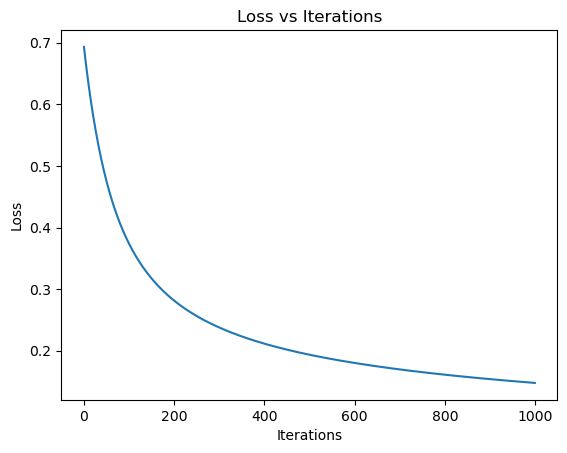

In [29]:
import matplotlib.pyplot as plt

plt.plot(model.losses)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [31]:
# Confustion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

tp = np.sum((predictions == 1) & (y_test == 1))
tn = np.sum((predictions == 0) & (y_test == 0))
fp = np.sum((predictions == 1) & (y_test == 0))
fn = np.sum((predictions == 0) & (y_test == 1))

print("Confustion matrix")
print("TP: ", tp, "FP: ", fp)
print("FN: ", fn, "TN: ", tn)

[[ 8  0]
 [ 1 11]]
Confustion matrix
TP:  0 FP:  0
FN:  0 TN:  0


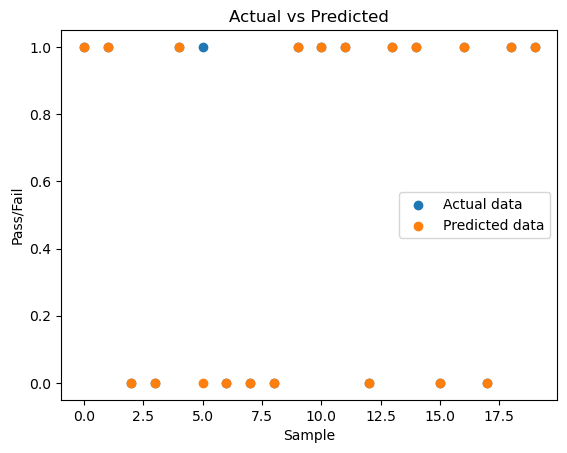

In [34]:
# Visualization
plt.scatter(range(len(y_test)), y_test, label="Actual data")
plt.scatter(range(len(y_test)), predictions, label="Predicted data")

plt.title("Actual vs Predicted")
plt.xlabel("Sample")
plt.ylabel("Pass/Fail")
plt.legend()

plt.show()